## **Business Problem**

Blinkit wants to improve its sales performance and profitability by understanding customer purchasing behavior, product performance, discount effectiveness, and revenue trends. However, the company lacks clear insights into which products and categories contribute the most to revenue and profit, making it difficult to optimize pricing, inventory, and marketing strategies.

## **Objective**

The objective of this project is to analyze Blinkit's sales data to identify high-performing products and categories, evaluate the impact of discounts and customer ratings on sales, and generate actionable business insights that support better pricing, inventory management, and marketing decisions.

## **Dataset Description**

The dataset contains Blinkit product and sales-related information across multiple product categories. It includes product details, pricing, discounts, customer ratings, reviews, delivery information, packaging details, and other attributes required to analyze sales performance and profitability.

The dataset is used to identify high-performing products and categories, evaluate the impact of discounts and customer ratings, and generate business insights that support pricing, inventory, and marketing decisions.

### **Key Features**

- Product ID
- Product Name
- Category
- Brand
- Price
- Discount Percentage
- Final Price
- Customer Rating
- Number of Reviews
- Delivery Time
- Organic Status
- Packaging Type
- Weight
- Shelf Life

**Import Libraries**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [6]:
df = pd.read_csv('blinkit_dataset.csv')

## **Data Understanding**

Before performing data cleaning and analysis, it is important to understand the structure, dimensions, data types, and summary statistics of the dataset. This helps identify missing values, incorrect data types, duplicates, and potential data quality issues.

In [7]:
df.shape

(13000, 25)

In [8]:
df.columns.tolist()

['product_id',
 'product_name',
 'category',
 'brand',
 'price',
 'discount_pct',
 'final_price',
 'rating',
 'num_reviews',
 'delivery_time_min',
 'city',
 'seller',
 'stock',
 'sold_quantity',
 'profit_margin_pct',
 'is_organic',
 'packaging_type',
 'weight_g',
 'shelf_life_days',
 'reorder_level',
 'demand_index',
 'date_added',
 'expiry_date',
 'offer_type',
 'delivery_status']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         13000 non-null  int64  
 1   product_name       13000 non-null  object 
 2   category           13000 non-null  object 
 3   brand              13000 non-null  object 
 4   price              13000 non-null  float64
 5   discount_pct       13000 non-null  int64  
 6   final_price        13000 non-null  float64
 7   rating             13000 non-null  float64
 8   num_reviews        13000 non-null  int64  
 9   delivery_time_min  13000 non-null  int64  
 10  city               13000 non-null  object 
 11  seller             13000 non-null  object 
 12  stock              13000 non-null  int64  
 13  sold_quantity      13000 non-null  int64  
 14  profit_margin_pct  13000 non-null  float64
 15  is_organic         13000 non-null  bool   
 16  packaging_type     130

In [10]:
df.head()

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,is_organic,packaging_type,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,146,37,...,True,Can,750,212,15,73,2023-11-27,2024-06-26,NaN,On-Time
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,...,False,Jar,1000,17,24,25,2024-08-07,2024-08-24,NaN,Delayed
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,69,17,...,True,Jar,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,103,23,...,True,Bottle,200,1143,18,15,2024-08-07,2027-09-24,NaN,On-Time
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,...,True,Can,300,363,30,6,2024-07-04,2025-07-02,NaN,On-Time


In [11]:
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
brand,0
price,0
discount_pct,0
final_price,0
rating,0
num_reviews,0
delivery_time_min,0


In [12]:
df.duplicated().sum()

np.int64(0)

## **Data Cleaning**

Data cleaning is performed to improve the quality of the dataset before analysis. This process includes checking for missing values, duplicate records, incorrect data types, invalid values, and ensuring the dataset is consistent and reliable for business analysis.

In [13]:
df['offer_type'] = df['offer_type'].fillna("No Offer")

## **Feature Engineering**

Feature engineering involves creating new business metrics from existing data to support deeper analysis. In this project, new features such as Revenue, Discount Amount, Profit per Unit, and Total Profit were created to evaluate sales performance and profitability more effectively.

In [14]:
# 1. Revenue (Most Important!)
df['revenue'] = df['final_price'] * df['sold_quantity']

# 2. Discount Amount
df['discount_amount'] = df['price'] - df['final_price']

# 3. Profit per unit
df['profit_per_unit'] = df['final_price'] * (df['profit_margin_pct'] / 100)

# 4. Total Profit
df['total_profit'] = df['profit_per_unit'] * df['sold_quantity']

print("New Columns Created Successfully!")
print("\nTop 5 rows of new columns:")
print(df[['final_price', 'sold_quantity', 'revenue', 'total_profit']].head())

print("\nTotal Revenue in Dataset: ₹", df['revenue'].sum().round(2))
print("Total Profit in Dataset: ₹", df['total_profit'].sum().round(2))

New Columns Created Successfully!

Top 5 rows of new columns:
   final_price  sold_quantity    revenue  total_profit
0       149.84            241   36111.44   10761.20912
1        31.02             28     868.56     132.02112
2       501.13            583  292158.79   19282.48014
3       627.17             33   20696.61    7616.35248
4        86.44             48    4149.12     601.62240

Total Revenue in Dataset: ₹ 509027130.44
Total Profit in Dataset: ₹ 115152653.08


## **Exploratory Data Analysis (EDA)**

Exploratory Data Analysis (EDA) is performed to identify trends, patterns, and relationships within the dataset. The analysis helps understand sales performance, customer purchasing behavior, profitability, and product performance to support data-driven business decisions.

**Revenue by category**

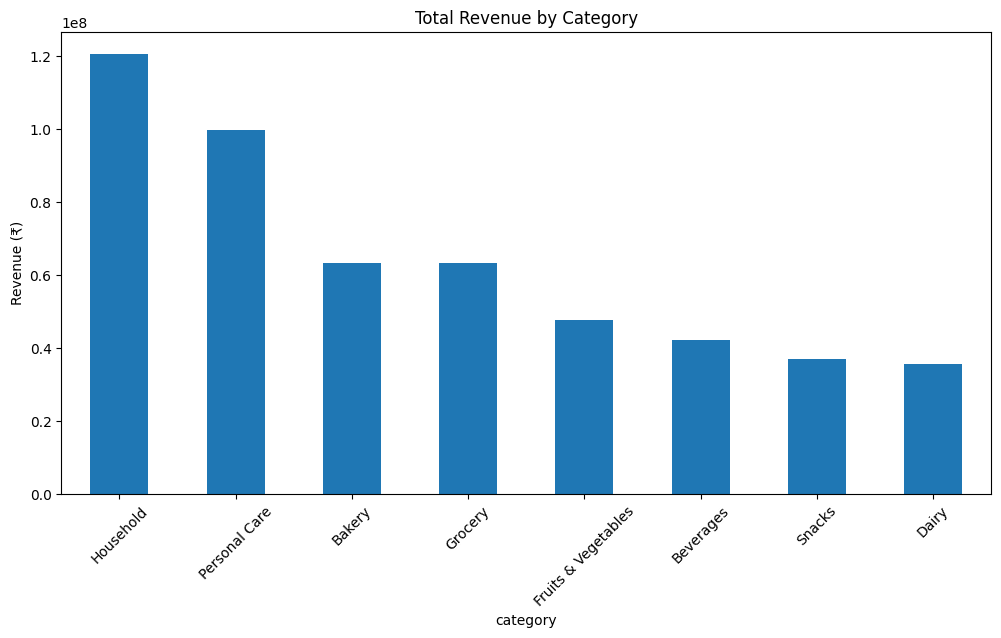

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
category_revenue.plot(kind='bar')
plt.title('Total Revenue by Category')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.show()

### Business Insight

- Household category generated the highest total revenue, making it the strongest revenue contributor.
- Personal Care is the second-highest revenue-generating category.
- Dairy and Snacks generated comparatively lower revenue.
- Blinkit should prioritize inventory, promotions, and marketing efforts for high-performing categories while investigating ways to improve the performance of lower-revenue categories.

**Top 10 Products by Revenue**

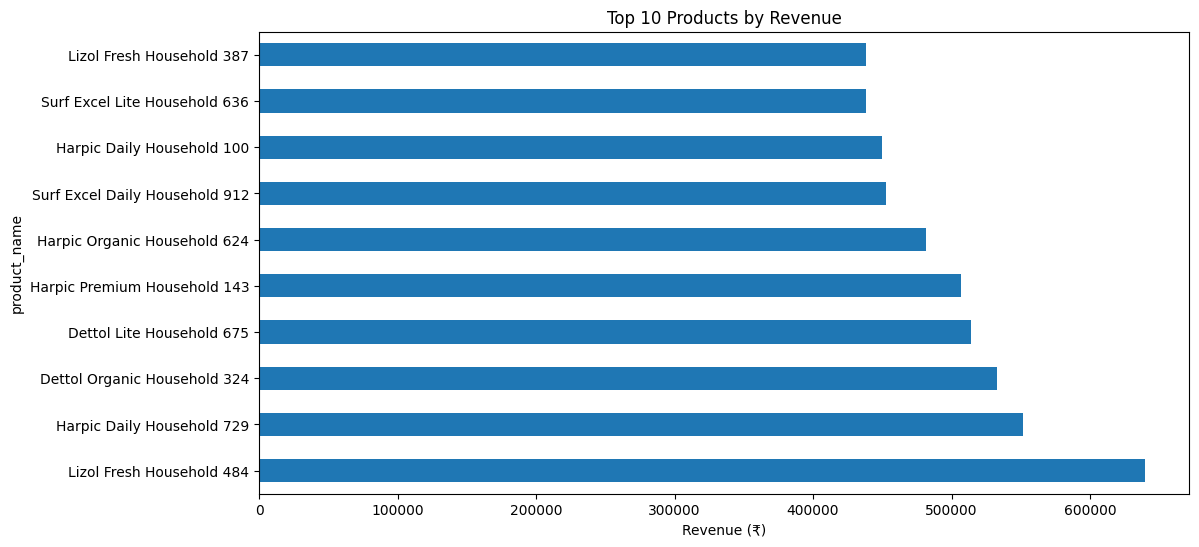

In [16]:
plt.figure(figsize=(12,6))
top_products = df.groupby('product_name')['revenue'].sum().nlargest(10)
top_products.plot(kind='barh')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (₹)')
plt.show()

### Business Insight

- The analysis highlights the top 10 revenue-generating products in the dataset.
- Household products dominate the top-performing products, indicating strong customer demand in this category.
- These products should be prioritized for inventory management, promotional campaigns, and stock availability to maximize revenue.
- Low stock levels for these products may directly impact overall sales performance.

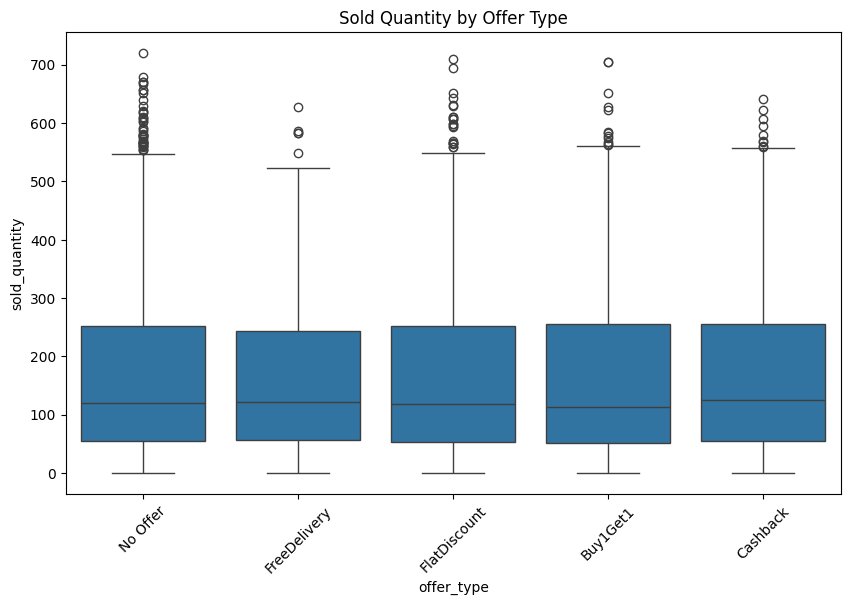

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(x='offer_type', y='sold_quantity', data=df)
plt.title('Sold Quantity by Offer Type')
plt.xticks(rotation=45)
plt.show()

### Business Insight

- The distribution of sold quantity is broadly similar across different offer types.
- Cashback and Flat Discount offers show slightly higher median sales compared to other offers.
- Every offer type contains a few high-selling products (outliers), indicating that product popularity also plays a major role in sales.
- Blinkit should evaluate offer performance together with revenue and profit before deciding which promotional strategy to expand.

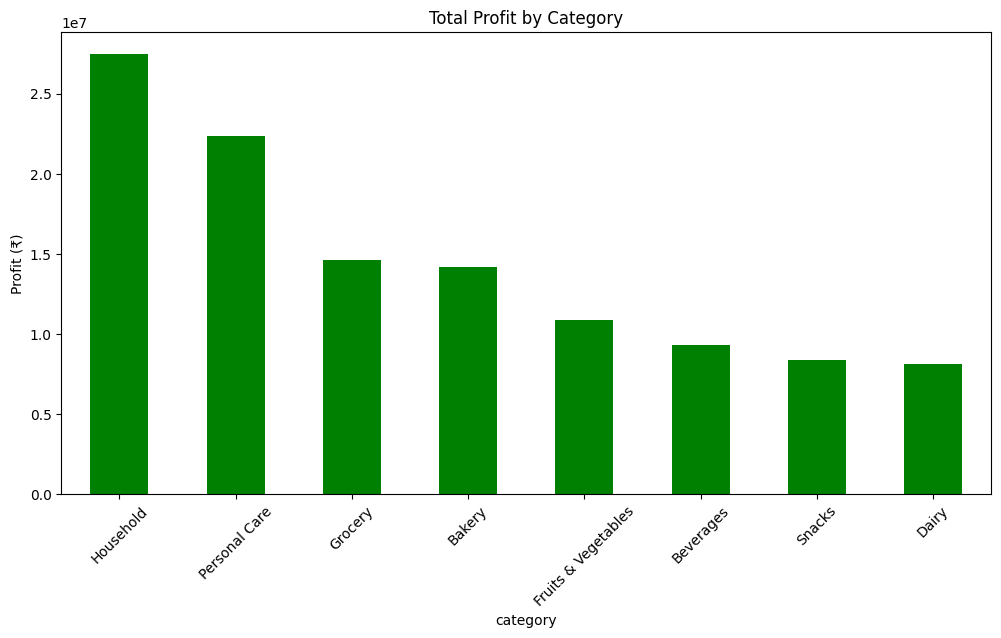

In [18]:
plt.figure(figsize=(12,6))
category_profit = df.groupby('category')['total_profit'].sum().sort_values(ascending=False)
category_profit.plot(kind='bar', color='green')
plt.title('Total Profit by Category')
plt.ylabel('Profit (₹)')
plt.xticks(rotation=45)
plt.show()

### Business Insight

- Household category generated the highest total profit, followed by Personal Care.
- Grocery and Bakery also contributed significantly to overall profitability.
- Dairy generated the lowest profit among all categories.
- Blinkit should prioritize high-profit categories while identifying strategies to improve the profitability of lower-performing categories.

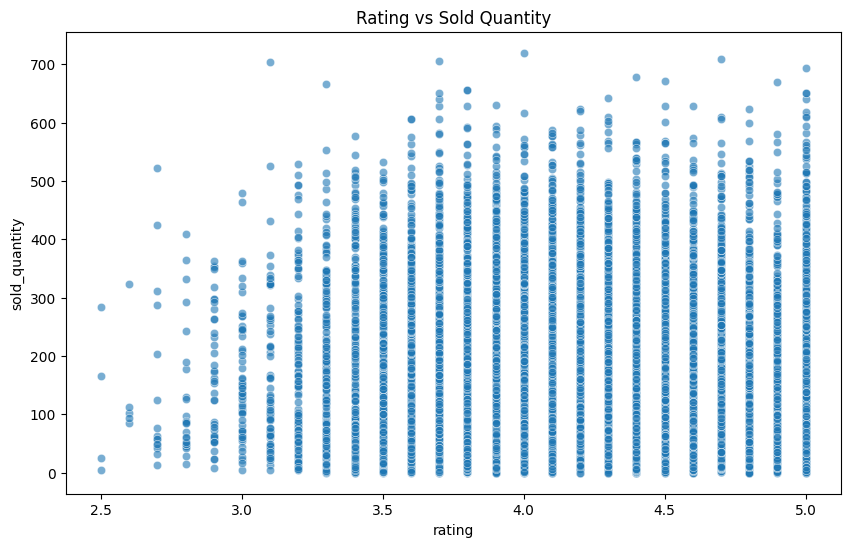

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='rating', y='sold_quantity', data=df, alpha=0.6)
plt.title('Rating vs Sold Quantity')
plt.show()

### Business Insight

- Products with higher customer ratings generally show higher sales potential.
- However, the relationship is not strong enough to conclude that ratings alone determine sales.
- Product pricing, category, promotions, and brand reputation are also likely to influence customer purchasing behavior.

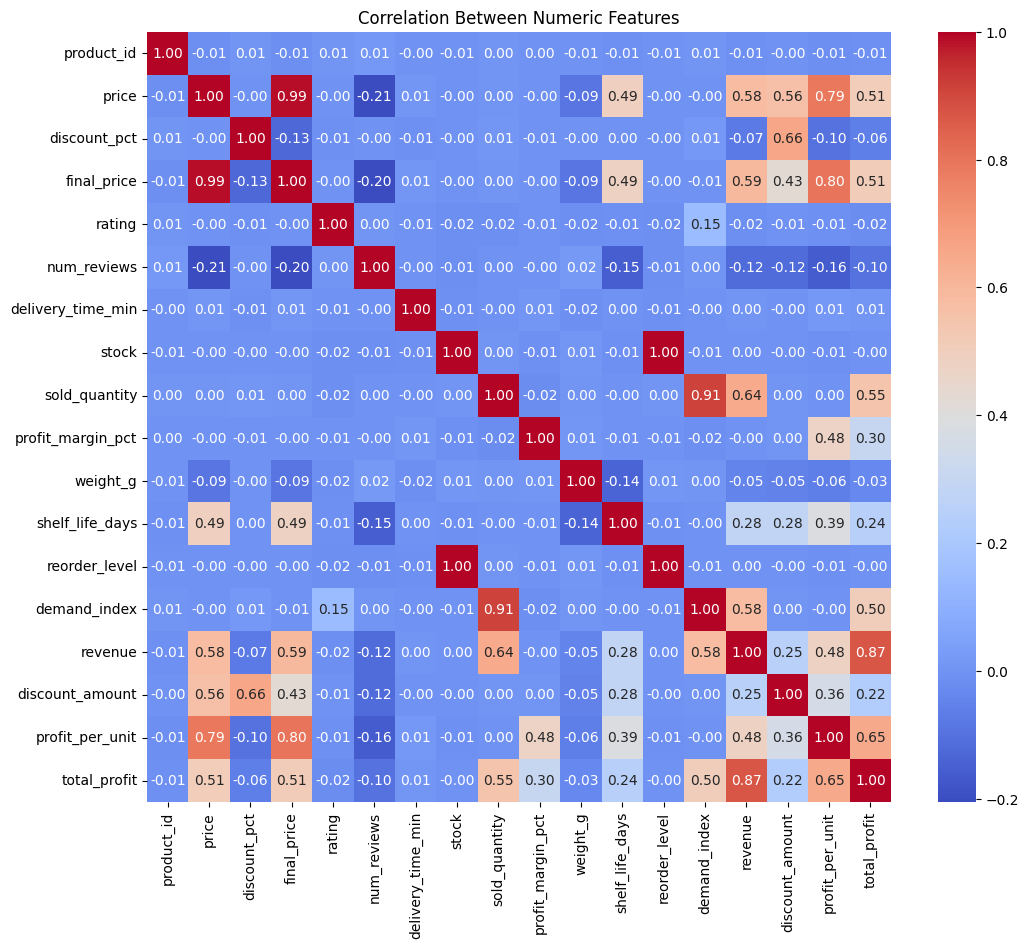

In [20]:
plt.figure(figsize=(12,10))
numeric_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numeric Features')
plt.show()

### Business Insight

- Demand Index has a strong positive correlation with Sold Quantity (0.91), indicating that products with higher demand achieve higher sales.
- Revenue and Total Profit are strongly correlated (0.87), showing that increasing revenue generally leads to higher profitability.
- Product Price has a strong positive relationship with Profit per Unit (0.79).
- Customer Rating has almost no correlation with Sold Quantity, suggesting that ratings alone do not significantly impact sales.